In [92]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
import scipy.linalg as sl

# Task 12

In [ ]:
# Transitions matrix
Q = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

# Parameters
n_states = len(Q)
n_sims = 1000

# List to store simulation results
W = []

# Random number generator
rng = np.random.default_rng(30)

for i in range(n_sims):
    # Inital parameters
    curr_state = 0
    t = 0
    n_observed = 0
    obs = [0]

    # Transition to states until death
    while True:
        # Define possible states to transition to as all states which is not the current state
        possible_states = [0,1,2,3,4]
        possible_states.pop(curr_state)

        # Sample time until a state change
        t += rng.exponential(-1/Q[curr_state,curr_state])

        # Sample new state
        new_state = rng.choice(a=possible_states, p=-1*(Q[curr_state,possible_states])/(Q[curr_state,curr_state]))

        # Find how many states we should have observed given current time
        new_n_observed = int(t/48)

        # If enough time has passed so we need new observations, make an appropriate number of observations of the old state
        if (new_n_observed != n_observed):
            for i in range(int(new_n_observed - n_observed)):
                obs.append(curr_state)
            n_observed = new_n_observed

        # If state is the last state (death) then stop and record final state
        if (new_state == 4):
            obs.append(4)
            break
        
        # Update current state
        curr_state = new_state

    W.append(obs)

In [94]:
W

[[0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 4],
 [0, 1, 1, 3, 4],
 [0, 0, 0, 0, 0, 4],
 [0, 0, 2, 2, 2, 4],
 [0, 2, 4],
 [0, 0, 0, 0, 0, 0, 1, 1, 1, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 2, 2, 2, 3, 3, 4],
 [0, 0, 0, 2, 2, 2, 3, 3, 4],
 [0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 4],
 [0, 0, 0, 1, 4],
 [0, 1, 1, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 3, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 0, 0, 2, 3, 3, 3, 4],
 [0, 1, 1, 1, 3, 4],
 [0, 0, 1, 2, 2, 4],
 [0, 4],
 [0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4],
 [0, 0, 4],
 [0, 1, 1, 4],
 [0, 1, 1, 4],
 [0, 4],
 [0, 0, 1, 3, 3, 4],
 [0, 1, 1, 4],
 [0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 4],
 [0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 4],
 [0, 0, 1, 4],
 [0, 0, 2, 2, 2, 2, 4],
 [0, 1, 2, 2, 2, 3, 3, 3, 4],
 [0, 0, 0, 1, 1, 4],
 [0, 1, 4],
 [0, 0, 2, 3, 4],
 [0, 0, 1, 1, 2, 2, 2, 2, 4],
 [0, 0, 0, 0, 0, 4],
 [0, 1, 4],
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 4],
 [0,

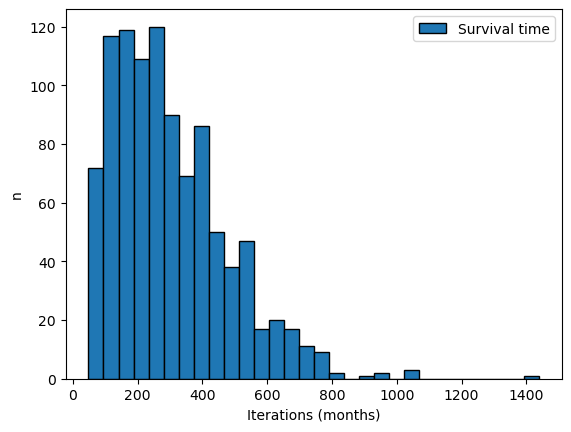

In [ ]:
lifetimes = np.zeros(n_sims)
for i in range(n_sims):
    lifetimes[i] = (len(W[i])-1)*48

plt.hist(lifetimes,bins=30, edgecolor="black", label="Observations from simulations")
plt.ylabel("Number of observations")
plt.xlabel("Survival time (months)")
plt.legend()
plt.show()

# Task 13

In [ ]:
# Initial guess for transistion matrix Q0
Q0 = np.array([
    [0, 0.01, 0.01, 0.01, 0.001],
    [0, 0, 0.01, 0.01, 0.01],
    [0, 0, 0, 0.01, 0.01],
    [0, 0, 0, 0, 0.01],
    [0, 0, 0, 0, 0]
])
for i in range(4):
    Q0[i,i] = -np.sum(Q0[i])

# Parameters
converged = False
tol = 1e-3
max_iter = 100
iter = 0
Q_arr = []

# Set current guess at Q to Q0
Qk = Q0
Q_arr.append(Qk)

# Run iterations updating Q until the tolerance or max iterations is reached 
while (not converged):
    # Initialize N_ij and S_i as zero for this iteration
    Nij = np.zeros((5,5))
    Si = np.zeros(5)

    # Perform an acceptable simulation of all women we have observations from
    for i in range(len(W)):

        # Boolean variable indicating if the current simulation of the current woman is accepted
        accepted = False

        if (i % 250 == 0):
            print(f'Simulating woman {i}...')

        # Simulate the current woman until a simulation which agree on the observations have been obtained
        while (not accepted):
            # Inital parameters
            curr_state = 0
            t = 0
            n_observed = 0
            sim_obs = [0]

            # Arrays to store states and time between states for the current simulation
            ts = [0]
            states = [0]

            # Run a full simulation of a woman
            while True:
                # Define possible states to transition to as all states which is not the current state
                possible_states = [0,1,2,3,4]
                possible_states.pop(curr_state)

                # Sample time until a state change
                t_new = rng.exponential(-1/Q[curr_state,curr_state])
                t += t_new

                # Sample new state
                new_state = rng.choice(a=possible_states, p=-1*(Qk[curr_state,possible_states])/(Qk[curr_state,curr_state]))

                # Record the exact time it took to change state to calculate S_i
                ts.append(t_new)
                states.append(new_state)

                # Find how many states we should have observed given current time
                new_n_observed = int(t/48)

                # If enough time has passed so we need new observations, make an appropriate number of observations of the old state
                if (new_n_observed != n_observed):
                    for m in range(int(new_n_observed - n_observed)):
                        sim_obs.append(curr_state)
                    n_observed = new_n_observed

                # If state is the last state (death) then stop and record final state
                if (new_state == 4):
                    sim_obs.append(4)
                    break
                
                # Update current state
                curr_state = new_state

            # Compare the current simulation to the observations for the current woman to determine if it is accepted
            same = True
            for j in range(len(W[i])):
                if (sim_obs[j] != W[i][j]):
                    same = False
                    break
            accepted = same

        # If the simulation is accepted, update N_ij and S_i
        for l in range(len(states)-1):
            Nij[states[l], states[l+1]] += 1
            Si[states[l]] += ts[l+1]

    # Once all women have been succesfully simulated, calculate new non-diagonal estimate of Q based on eq. 2
    new_Q = np.zeros((5,5))
    # (We always set the last row of Q to zero since they cannot transistion of out death)
    for n in range(4):
        for o in range(5):
            if (Nij[n,o] == 0):
                new_Q[n,o] = 0
            else:
                new_Q[n,o] = Nij[n,o] / Si[n]

    # Set diagonal elements of new Q according to eq. 1
    for k in range(4):
        new_Q[k,k] = -np.sum(new_Q[k])

    iter += 1
    Qk = new_Q
    Q_arr.append(Qk)

    print('Performed one iteration, new estimate of Q is:')
    print(Qk)

    # Check for convergence according to the tolerance set
    converged = np.max(np.abs(Qk - new_Q)) <= tol

    # Check if we reach max iterations
    if (iter >= max_iter):
        print('Reached max iterations, terminating...')
        break

Woman 0
Woman 100
Woman 200
Woman 300
Woman 400
Woman 500
Woman 600
Woman 700
Woman 800
Woman 900
Performed one iteration, new Q is:
[[-0.0082439   0.00382517  0.00279468  0.0012201   0.00040395]
 [ 0.         -0.01255842  0.00389744  0.0040057   0.00465528]
 [ 0.          0.         -0.00785907  0.00328681  0.00457225]
 [ 0.          0.          0.         -0.01141827  0.01141827]
 [ 0.          0.          0.          0.          0.        ]]
Woman 0
Woman 100
Woman 200
Woman 300
Woman 400
Woman 500
Woman 600
Woman 700
Woman 800
Woman 900
Performed one iteration, new Q is:
[[-0.0082782   0.00438744  0.00283942  0.00062086  0.00043047]
 [ 0.         -0.01395855  0.00447727  0.0037135   0.00576778]
 [ 0.          0.         -0.00830682  0.00310899  0.00519784]
 [ 0.          0.          0.         -0.00971326  0.00971326]
 [ 0.          0.          0.          0.          0.        ]]
Woman 0
Woman 100
Woman 200
Woman 300
Woman 400
Woman 500
Woman 600
Woman 700
Woman 800
Woman 900
Perf

In [98]:
print(np.max(np.abs(Q - Qk)))

0.0013461120147546645
